# CSE5280 — Building Evacuation Simulation
**Author:** Matteo Caruso  
**Course:** CSE5280 — Computer Vision & Simulation  
**Date:** Spring 2026

---

## Table of Contents
1. [Environment Setup](#setup)
2. [Mathematical Framework](#math)
3. [Building Geometry & Ramp Model](#geometry)
4. [Cost Function Design](#cost)
5. [Agent Initialization](#agents)
6. [Gradient Descent Optimizer](#optimizer)
7. [3D Visualization with Vedo](#viz)
8. [Simulation Runner](#sim)
9. [Experiments & Analysis](#experiments)
10. [Discussion & Bottleneck Analysis](#discussion)

---

### Overview

This notebook implements a **multi-agent building evacuation simulation** using a cost-function minimization framework. All agent motion emerges entirely from gradient descent on a scalar cost landscape — no path planning, no hard-coded routing, and no discrete floor-switching logic.

The building consists of **three floors** connected by **two ramps**. Agents must navigate from their starting positions on any floor down to one of **two exits** on the ground floor. Exit selection is governed by a **soft-min function**, producing a realistic crowd split.

**Key design principles:**
- Motion = $-\nabla C_{\text{total}}$
- All floor transitions are continuous (ramp surface adherence)
- Exit selection via smooth soft-min, never `argmin`
- Social forces prevent particle overlap

In [1]:
#@title # 1. Environment Setup { display-mode: "form" }
#@markdown Install `vedo`, set up virtual display for Colab rendering, and import all dependencies.

!pip install -q vedo k3d
!apt-get install -q -y xvfb freeglut3-dev ffmpeg > /dev/null 2>&1

import os
os.system("Xvfb :1 -screen 0 1920x1080x24 &")
os.environ['DISPLAY'] = ':1'

import numpy as np
import matplotlib.pyplot as plt
import vedo
from vedo import *
from vedo import settings as vedo_settings

# Use k3d backend for inline Colab display
vedo_settings.default_backend = 'k3d'

print("Environment ready. vedo version:", vedo.__version__)

Environment ready. vedo version: 2026.6.1


## 2. Mathematical Framework <a name="math"></a>

### 2.1 Total Cost Function

The total cost for each agent $i$ at position $\mathbf{p}_i = (x, y, z)$ is:

$$C_{\text{total}}(\mathbf{p}) = C_{\text{goal}} + C_{\text{walls}} + C_{\text{height}} + C_{\text{smooth}} + C_{\text{repulsion}}$$

---

### 2.2 Goal Attraction — Soft-Min

Let $\mathbf{p}^{\text{exit}}_1, \mathbf{p}^{\text{exit}}_2$ be the two ground-floor exit locations. Define the distance cost to each:

$$C_i(\mathbf{p}) = \|\mathbf{p} - \mathbf{p}^{\text{exit}}_i\|^2$$

A hard minimum $\min(C_1, C_2)$ is **not permitted** — it is non-differentiable. Instead, the **soft-min** is used:

$$C_{\text{goal}}(\mathbf{p}) = -\tau \log\left(\sum_{i=1}^{2} \exp\left(-\frac{C_i(\mathbf{p})}{\tau}\right)\right)$$

Its gradient is a **weighted combination** of individual exit gradients:

$$\nabla C_{\text{goal}} = \sum_i w_i \nabla C_i, \qquad w_i = \frac{\exp(-C_i/\tau)}{\sum_j \exp(-C_j/\tau)}$$

**Temperature parameter:** $0.5 \leq \tau \leq 1.5$. Smaller $\tau$ sharpens exit preference; larger $\tau$ blends exits more uniformly.

---

### 2.3 Surface-Adherence Cost

Agents must remain constrained to the building surfaces (floors + ramps). This is enforced by a quadratic height penalty:

$$C_{\text{height}} = w_h \left(z - z_{\text{surf}}(x, y)\right)^2$$

where the surface height blends floor and ramp heights:

$$z_{\text{surf}}(x, y) = \bigl(1 - g(x,y)\bigr)\, z_{\text{floor}} + g(x,y)\, z_{\text{ramp}}(x,y)$$

$$g(x,y) = \begin{cases} 1 & \text{if } (x,y) \in \mathcal{R} \\ 0 & \text{otherwise} \end{cases}$$

---

### 2.4 Ramp Height Function

A ramp connects floor $z_0$ (top) to floor $z_1$ (bottom) along a centerline $[\mathbf{A}, \mathbf{B}]$ with half-width $r$.

**Direction vector:** $\mathbf{v} = \mathbf{B} - \mathbf{A}$

**Projection parameter:**
$$t = \frac{(\mathbf{P} - \mathbf{A}) \cdot \mathbf{v}}{\mathbf{v} \cdot \mathbf{v}}, \qquad u(x,y) = \text{clip}(t,\, 0,\, 1)$$

**Linear height interpolation:**
$$z_{\text{ramp}}(x,y) = z_0 + (z_1 - z_0)\, u(x,y)$$

**Footprint (capsule corridor):**
$$\mathcal{R} = \left\{(x,y) \;\middle|\; \text{dist}\bigl((x,y),\, [\mathbf{A},\mathbf{B}]\bigr) \leq r\right\}$$

---

### 2.5 Wall Penalty

Using a **Gaussian** penalty for smooth repulsion from wall segments:

$$C_{\text{walls}} = \sum_k w_k \exp\left(-\frac{d_k(\mathbf{p})^2}{2\sigma^2}\right)$$

---

### 2.6 Smoothness & Agent Repulsion

$$C_{\text{smooth}} = \|\mathbf{p}^{k+1} - \mathbf{p}^k\|^2$$

$$C_{\text{repulsion}} = \sum_{i \neq j} \exp\left(-\frac{\|\mathbf{p}_i - \mathbf{p}_j\|^2}{2\sigma_r^2}\right)$$

---

### 2.7 Gradient Descent Update

Each agent updates its position via:

$$\mathbf{p}^{k+1} = \mathbf{p}^k - \alpha \nabla C_{\text{total}}(\mathbf{p}^k)$$

with step-size capping: $\|\Delta \mathbf{p}\| \leq \delta_{\max}$, and momentum smoothing: $\mathbf{v}^{k+1} = \beta \mathbf{v}^k - \alpha \nabla C$.

In [2]:
#@title # 3. Building Geometry & Ramp Model { display-mode: "form" }
#@markdown Defines floor heights, wall segments, ramp parameters, and exit locations.

# ─── Global Building Parameters ───────────────────────────────────────────────
H       = 4.0    # Floor-to-floor height
FLOOR_W = 20.0   # Building half-width (x)
FLOOR_D = 15.0   # Building half-depth (y)

# Floor z-levels
Z_GND   = 0.0
Z_1ST   = H
Z_2ND   = 2 * H

# ─── Exit Locations (ground floor only) ───────────────────────────────────────
EXIT_A  = np.array([FLOOR_W - 1.0, -FLOOR_D + 1.0, Z_GND])   # South-East exit
EXIT_B  = np.array([-(FLOOR_W - 1.0), -FLOOR_D + 1.0, Z_GND]) # South-West exit
EXITS   = [EXIT_A, EXIT_B]

# ─── Ramp Definitions ─────────────────────────────────────────────────────────
# Each ramp: centerline (A, B), half-width r, top_z, bot_z
# Ramp 1: 2nd Floor → 1st Floor (east side)
RAMP1 = {
    'A':     np.array([8.0,  6.0]),   # Top of ramp (2nd floor)
    'B':     np.array([8.0, -2.0]),   # Bottom of ramp (1st floor)
    'z_top': Z_2ND,
    'z_bot': Z_1ST,
    'r':     2.0,                     # Half-width
    'label': 'Ramp 2F→1F (East)'
}

# Ramp 2: 1st Floor → Ground Floor (west side)
RAMP2 = {
    'A':     np.array([-8.0,  6.0]),  # Top of ramp (1st floor)
    'B':     np.array([-8.0, -2.0]),  # Bottom of ramp (ground floor)
    'z_top': Z_1ST,
    'z_bot': Z_GND,
    'r':     2.0,
    'label': 'Ramp 1F→GF (West)'
}

ALL_RAMPS = [RAMP1, RAMP2]

# ─── Interior Walls per Floor [x0,y0, x1,y1] ──────────────────────────────────
# Internal walls are SHORT (height 1.5) so agents are visible
# Back/boundary walls are TALL (height 6.0)

WALLS_GND = [
    # Central dividing wall with gap for agents
    {'seg': [(-5.0, 2.0, 5.0, 2.0)],  'height': 1.5, 'z': Z_GND},
    {'seg': [(0.0, -5.0, 0.0, 2.0)],   'height': 1.5, 'z': Z_GND},
]
WALLS_1ST = [
    {'seg': [(-6.0, 0.0, 2.0, 0.0)],   'height': 1.5, 'z': Z_1ST},
    {'seg': [(4.0, -6.0, 4.0, 3.0)],   'height': 1.5, 'z': Z_1ST},
]
WALLS_2ND = [
    # Upper wall: blocks the direct path, forces agents to slide right
    {'seg': [(-6.0, 2.0, 3.0, 2.0)],   'height': 1.5, 'z': Z_2ND},
]

# ─── Ramp Geometry Functions ───────────────────────────────────────────────────

def ramp_projection_param(xy, ramp):
    """Compute clamped projection parameter u ∈ [0,1] along ramp centerline."""
    A = ramp['A']
    v = ramp['B'] - A
    denom = np.dot(v, v)
    if denom < 1e-12:
        return 0.0
    t = np.dot(xy - A, v) / denom
    return np.clip(t, 0.0, 1.0)

def ramp_height(xy, ramp):
    """Returns ramp height at 2D position xy."""
    u = ramp_projection_param(xy, ramp)
    return ramp['z_top'] + (ramp['z_bot'] - ramp['z_top']) * u

def point_to_segment_dist(xy, A, B):
    """Minimum distance from point xy to segment [A, B]."""
    v = B - A
    denom = np.dot(v, v)
    if denom < 1e-12:
        return np.linalg.norm(xy - A)
    t = np.clip(np.dot(xy - A, v) / denom, 0.0, 1.0)
    closest = A + t * v
    return np.linalg.norm(xy - closest)

def in_ramp_footprint(xy, ramp):
    """Returns True if 2D point xy lies within the ramp capsule footprint."""
    dist = point_to_segment_dist(xy, ramp['A'], ramp['B'])
    return dist <= ramp['r']

def surface_height(pos, floor_z):
    """
    Returns z_surf for a given (x,y) position and the agent's current floor_z.
    Agents only 'see' the ramp assigned to their current floor transition.
    """
    xy = pos[:2]

    # Which ramp should this agent be looking for?
    if floor_z >= Z_2ND - 0.5:
        target_ramp = RAMP1  # Floor 2 agents use Ramp 1
    elif floor_z >= Z_1ST - 0.5:
        target_ramp = RAMP2  # Floor 1 agents use Ramp 2
    else:
        return Z_GND         # Ground floor is flat

    # If they are inside their target ramp's footprint, adhere to its incline
    if in_ramp_footprint(xy, target_ramp):
        # But ONLY if they haven't reached the bottom yet!
        ramp_z = ramp_height(xy, target_ramp)
        if pos[2] > target_ramp['z_bot'] - 0.1:
            return ramp_z

    return floor_z

def assign_floor(z):
    """Return the canonical floor z-level closest to given z."""
    levels = [Z_GND, Z_1ST, Z_2ND]
    return levels[np.argmin([abs(z - lv) for lv in levels])]

print("Building geometry defined.")
print(f"  Exits: A={EXIT_A}, B={EXIT_B}")
print(f"  Ramp 1: {RAMP1['A']} → {RAMP1['B']} ({RAMP1['z_top']}→{RAMP1['z_bot']})")
print(f"  Ramp 2: {RAMP2['A']} → {RAMP2['B']} ({RAMP2['z_top']}→{RAMP2['z_bot']})")

Building geometry defined.
  Exits: A=[ 19. -14.   0.], B=[-19. -14.   0.]
  Ramp 1: [8. 6.] → [ 8. -2.] (8.0→4.0)
  Ramp 2: [-8.  6.] → [-8. -2.] (4.0→0.0)


In [3]:
#@title # 4. Cost Function Design { display-mode: "form" }
#@markdown All cost terms: Soft-Min goal attraction, wall penalties,
#@markdown height adherence, smoothness, and agent repulsion.

# ─── Hyperparameters ──────────────────────────────────────────────────────────
TAU           = 1.0    # Soft-min temperature  (0.5 – 1.5)
W_GOAL        = 1.0    # Goal attraction weight
W_HEIGHT      = 80.0   # Surface adherence stiffness
W_WALL        = 15.0   # Wall repulsion weight
SIGMA_WALL    = 1.2    # Wall Gaussian width
W_REPULSION   = 3.0    # Agent repulsion weight
SIGMA_REP     = 1.5    # Agent repulsion width
W_SMOOTH      = 0.05   # Smoothness weight
W_RAMP_ATTRACT= 2.5    # Ramp attraction weight

# ─── 4.1 Soft-Min Goal Cost ───────────────────────────────────────────────────

def cost_goal_softmin(pos, exits=EXITS, tau=TAU):
    """
    Soft-min cost toward multiple exits.
    C_goal(p) = -τ log( Σ exp(-C_i(p) / τ) )
    """
    costs = np.array([np.sum((pos - e)**2) for e in exits])
    # Stable log-sum-exp trick
    c_min = np.min(costs)
    log_sum = c_min - tau * np.log(np.sum(np.exp(-(costs - c_min) / tau)))
    return log_sum

def grad_goal_softmin(pos, exits=EXITS, tau=TAU):
    """
    ∇C_goal = Σ_i w_i ∇C_i
    where w_i = exp(-C_i/τ) / Σ_j exp(-C_j/τ)
    """
    costs = np.array([np.sum((pos - e)**2) for e in exits])
    c_min = np.min(costs)
    exp_vals = np.exp(-(costs - c_min) / tau)
    weights = exp_vals / np.sum(exp_vals)
    grad = np.zeros(3)
    for i, e in enumerate(exits):
        grad += weights[i] * 2.0 * (pos - e)
    return grad

# ─── 4.2 Wall Penalty (Gaussian) ─────────────────────────────────────────────

def _pt_seg_dist_3d(pos, p0, p1):
    """3D distance from pos to line segment [p0, p1]."""
    v = p1 - p0
    denom = np.dot(v, v)
    if denom < 1e-12:
        return np.linalg.norm(pos - p0)
    t = np.clip(np.dot(pos - p0, v) / denom, 0.0, 1.0)
    return np.linalg.norm(pos - (p0 + t * v))

def _build_wall_segments():
    """Convert wall definitions to 3D segment pairs for all floors."""
    segs = []
    for floor_walls, floor_z in [
        (WALLS_GND, Z_GND), (WALLS_1ST, Z_1ST), (WALLS_2ND, Z_2ND)
    ]:
        for w in floor_walls:
            x0, y0, x1, y1 = w['seg'][0]
            h = w['height']
            z = w['z']
            p0 = np.array([x0, y0, z])
            p1 = np.array([x1, y1, z + h])
            segs.append((p0, p1))
    return segs

WALL_SEGMENTS = _build_wall_segments()

def cost_walls(pos, sigma=SIGMA_WALL):
    """Gaussian wall repulsion: Σ_k exp(-d_k² / 2σ²)"""
    c = 0.0
    for p0, p1 in WALL_SEGMENTS:
        d = _pt_seg_dist_3d(pos, p0, p1)
        c += np.exp(-d**2 / (2 * sigma**2))
    return c

def grad_walls(pos, sigma=SIGMA_WALL, eps=1e-4):
    """Numerical gradient of wall cost."""
    grad = np.zeros(3)
    for i in range(3):
        pp, pm = pos.copy(), pos.copy()
        pp[i] += eps; pm[i] -= eps
        grad[i] = (cost_walls(pp, sigma) - cost_walls(pm, sigma)) / (2 * eps)
    return grad

# ─── 4.3 Surface-Adherence (Height) Cost ─────────────────────────────────────

def cost_height(pos, floor_z):
    """
    C_height = w_h * (z - z_surf(x,y))²
    Penalizes deviation from the building surface.
    """
    z_surf = surface_height(pos, floor_z)
    return (pos[2] - z_surf)**2

def grad_height(pos, floor_z):
    """
    Analytical gradient of height cost.
    CRITICAL FIX: Forces are ONLY applied in the Z-direction.
    This prevents massive horizontal 'forcefields' when agents touch the edge
    of a ramp footprint.
    """
    z_surf = surface_height(pos, floor_z)
    grad = np.zeros(3)
    # ∇C_height = 2 * (z - z_surf) purely in the Z axis
    grad[2] = 2.0 * (pos[2] - z_surf)
    return grad

# ─── 4.4 Ramp Attraction Gradient (Analytical) ────────────────────────────────

def grad_ramp_attraction(pos, floor_z):
    """
    Analytical gradient to guide agents TO the ramp, and then DOWN it.
    Strict Z-bounds prevent agents on upper floors from being trapped
    by the footprints of ramps below them.
    """
    if floor_z <= Z_GND + 0.5:
        return np.zeros(3)

    xy = pos[:2]
    z = pos[2]

    # Are they physically currently on Ramp 1? (Must be within Z-bounds)
    on_ramp1 = in_ramp_footprint(xy, RAMP1) and (RAMP1['z_bot'] <= z <= RAMP1['z_top'] + 0.5)
    # Are they physically currently on Ramp 2? (Must be within Z-bounds)
    on_ramp2 = in_ramp_footprint(xy, RAMP2) and (RAMP2['z_bot'] <= z <= RAMP2['z_top'] + 0.5)

    if on_ramp1 and z > RAMP1['z_bot'] + 0.2:
        target_xy = RAMP1['B']
    elif on_ramp2 and z > RAMP2['z_bot'] + 0.2:
        target_xy = RAMP2['B']
    elif floor_z >= Z_2ND - 0.5:
        target_xy = RAMP1['A']
    else:
        target_xy = RAMP2['A']

    diff = xy - target_xy
    dist = np.linalg.norm(diff)

    grad = np.zeros(3)
    if dist > 1e-4:
        # Strictly horizontal pull
        grad[:2] = diff / dist

    return grad

# ─── 4.5 Agent Repulsion ──────────────────────────────────────────────────────

def grad_repulsion_for_agent(i, positions, sigma=SIGMA_REP):
    """
    Social force repulsion.
    Restricted to 2D horizontal forces between agents on the SAME floor
    to prevent cross-floor interference.
    """
    pos_i = positions[i]
    grad  = np.zeros(3)
    for j, pos_j in enumerate(positions):
        if i == j:
            continue

        # CRITICAL: Ignore agents on other floors!
        if abs(pos_i[2] - pos_j[2]) > 1.0:
            continue

        diff  = pos_i - pos_j
        # Force the repulsion to be strictly horizontal (2D)
        diff[2] = 0.0

        d_sq  = np.dot(diff, diff)
        if d_sq < 1e-4:
            continue

        w     = np.exp(-d_sq / (2 * sigma**2))
        grad += w * (-diff / (sigma**2))

    return -grad

# ─── 4.6 Total Cost Gradient for One Agent ────────────────────────────────────

def total_gradient(i, positions, floor_z, prev_pos):
    """
    Compute total gradient. Disables global exit attraction for upper floors
    so it doesn't fight the ramp attraction.
    """
    pos = positions[i]
    g = np.zeros(3)

    # 1. Floor-specific navigation (Mutually Exclusive!)
    if floor_z <= Z_GND + 0.5:
        # Ground floor: ONLY feel the pull of the soft-min exits
        g += W_GOAL * grad_goal_softmin(pos)
    else:
        # Upper floors: ONLY feel the pull of the ramps
        g += W_RAMP_ATTRACT * grad_ramp_attraction(pos, floor_z)

    # 2. Universal physics/constraints (Everyone feels these)
    g += W_HEIGHT      * grad_height(pos, floor_z)
    g += W_WALL        * grad_walls(pos)
    g += W_REPULSION   * grad_repulsion_for_agent(i, positions)
    g += W_SMOOTH      * 2.0 * (pos - prev_pos)

    return g

print("Cost functions defined.")
# Quick sanity check
test_pos = np.array([5.0, 5.0, Z_2ND])
test_g = grad_goal_softmin(test_pos)
print(f"  Soft-min gradient at {test_pos}: {test_g.round(3)}")

Cost functions defined.
  Soft-min gradient at [5. 5. 8.]: [-28.  38.  16.]


In [4]:
#@title # 5. Agent Initialization { display-mode: "form" }
#@markdown Randomly distributes agents across all three floors.
#@markdown Each agent has a position, velocity (momentum), and floor label.

def initialize_agents(n_agents=50, seed=42):
    """
    Distribute n_agents across the three floors.
    Avoids placing agents directly on ramp regions.

    Returns:
        positions : (N, 3) array
        velocities: (N, 3) array  (zero-initialized)
        floor_zs  : (N,) array — canonical floor z for each agent
        prev_pos  : (N, 3) array  (copy of initial positions)
        active    : (N,) bool array — False once agent reaches exit
    """
    rng = np.random.default_rng(seed)

    floors = [Z_GND, Z_1ST, Z_2ND]
    per_floor = n_agents // 3
    remainder = n_agents % 3

    counts = [per_floor, per_floor, per_floor]
    for i in range(remainder):
        counts[i] += 1

    positions  = []
    floor_zs   = []

    for floor_idx, (fz, count) in enumerate(zip(floors, counts)):
        placed = 0
        attempts = 0
        while placed < count and attempts < 10000:
            attempts += 1
            x = rng.uniform(-(FLOOR_W - 2), FLOOR_W - 2)
            y = rng.uniform(-(FLOOR_D - 2), FLOOR_D - 2)
            xy = np.array([x, y])

            # Skip ramp regions to avoid overlapping geometry
            on_ramp = any(in_ramp_footprint(xy, r) for r in ALL_RAMPS)
            if on_ramp:
                continue

            positions.append(np.array([x, y, fz]))
            floor_zs.append(fz)
            placed += 1

    positions  = np.array(positions)
    velocities = np.zeros_like(positions)
    floor_zs   = np.array(floor_zs)
    prev_pos   = positions.copy()
    active     = np.ones(len(positions), dtype=bool)

    return positions, velocities, floor_zs, prev_pos, active

# Test initialization
pos_test, _, fz_test, _, _ = initialize_agents(30)
print(f"Initialized {len(pos_test)} agents")
for fz in [Z_GND, Z_1ST, Z_2ND]:
    n = np.sum(fz_test == fz)
    print(f"  Floor z={fz:.1f}: {n} agents")

Initialized 30 agents
  Floor z=0.0: 10 agents
  Floor z=4.0: 10 agents
  Floor z=8.0: 10 agents


In [5]:
#@title # 6. Gradient Descent Optimizer { display-mode: "form" }
#@markdown Step-size capping, momentum smoothing, floor tracking, and exit detection.

ALPHA       = 0.04    # Base learning rate
BETA        = 0.6     # Momentum coefficient
MAX_STEP    = 0.30    # Step-size cap (prevents explosions)
EXIT_THRESH = 1.2     # Distance to exit to declare evacuation

def update_floor_z(pos, old_floor_z):
    """
    Update agent's canonical floor level based on current z.
    Uses a hysteresis band to avoid rapid flickering.
    """
    z = pos[2]
    # If agent has descended significantly, update their floor level
    if z < old_floor_z - 0.3:
        return assign_floor(z)
    return old_floor_z

def step_agents(positions, velocities, floor_zs, prev_pos, active):
    """
    Perform one gradient descent step for all active agents.

    Update rule:
        v^{k+1} = β v^k - α ∇C
        p^{k+1} = p^k + clip(v^{k+1}, max_step)
    """
    new_positions  = positions.copy()
    new_velocities = velocities.copy()
    new_floor_zs   = floor_zs.copy()
    new_prev       = prev_pos.copy()
    new_active     = active.copy()

    for i in range(len(positions)):
        if not active[i]:
            continue

        # Check if reached any exit
        for ex in EXITS:
            if np.linalg.norm(positions[i] - ex) < EXIT_THRESH:
                new_active[i] = False
                break

        if not new_active[i]:
            continue

        # Compute total gradient
        g = total_gradient(i, positions, floor_zs[i], prev_pos[i])

        # Momentum update
        v_new = BETA * velocities[i] - ALPHA * g

        # Step-size cap
        step_norm = np.linalg.norm(v_new)
        if step_norm > MAX_STEP:
            v_new = v_new * (MAX_STEP / step_norm)

        new_pos = positions[i] + v_new

        # Hard clamp to building bounds
        new_pos[0] = np.clip(new_pos[0], -FLOOR_W + 0.5, FLOOR_W - 0.5)
        new_pos[1] = np.clip(new_pos[1], -FLOOR_D + 0.5, FLOOR_D - 0.5)
        new_pos[2] = np.clip(new_pos[2], Z_GND - 0.5,  Z_2ND + 0.5)

        new_prev[i]       = positions[i]
        new_positions[i]  = new_pos
        new_velocities[i] = v_new
        new_floor_zs[i]   = update_floor_z(new_pos, floor_zs[i])

    return new_positions, new_velocities, new_floor_zs, new_prev, new_active

print("Optimizer configured.")
print(f"  α={ALPHA}, β={BETA}, max_step={MAX_STEP}, exit_thresh={EXIT_THRESH}")

Optimizer configured.
  α=0.04, β=0.6, max_step=0.3, exit_thresh=1.2


In [6]:
#@title # 7. 3D Visualization with Vedo { display-mode: "form" }
#@markdown Creates the professional 3D building mesh, ramp planes,
#@markdown exit markers, and agent spheres with Lambertian shading and solid walls.

# Color palette (Clean, Architectural Style)
CLR_FLOOR     = [235, 235, 235]   # light gray floor
CLR_WALL_INT  = [255, 255, 255]   # crisp white internal walls
CLR_WALL_EXT  = [220, 220, 220]   # slightly darker external walls for depth
CLR_RAMP      = [190, 150, 110]   # warm wood-tone ramps
CLR_EXIT_A    = [120, 180, 120]   # matte green exit A
CLR_EXIT_B    = [120, 150, 190]   # matte blue exit B
CLR_AGENT_GND = [200,  60,  60]   # red — ground floor
CLR_AGENT_1ST = [220, 140,  30]   # orange — 1st floor
CLR_AGENT_2ND = [60,  140, 220]   # blue — 2nd floor
CLR_EVACUATED = [180, 180, 180]   # grey — evacuated

AGENT_RADIUS  = 0.35

def apply_matte_shading(mesh):
    """Applies a diffuse, non-shiny lighting model for an architectural look."""
    # Using 'default' but killing the specular reflection gives us pure Lambertian shading
    return mesh.lighting('default', ambient=0.4, diffuse=0.6, specular=0.0)

def make_floor_slab(z, w=FLOOR_W, d=FLOOR_D, thickness=0.15):
    """Create a semi-transparent floor slab."""
    slab = Box(
        pos=(0, 0, z - thickness/2),
        length=2*w, width=2*d, height=thickness,
        c=CLR_FLOOR, alpha=0.3
    )
    return apply_matte_shading(slab)

def make_boundary_walls(z, wall_h=5.5, w=FLOOR_W, d=FLOOR_D, t=0.3):
    """Create the tall solid boundary walls on three sides."""
    walls = []
    hw = wall_h / 2
    # Back wall (y = +d)
    walls.append(Box(pos=(0, d, z + hw), length=2*w, width=t, height=wall_h, c=CLR_WALL_EXT))
    # Left wall
    walls.append(Box(pos=(-w, 0, z + hw), length=t, width=2*d, height=wall_h, c=CLR_WALL_EXT))
    # Right wall
    walls.append(Box(pos=(w, 0, z + hw), length=t, width=2*d, height=wall_h, c=CLR_WALL_EXT))
    return [apply_matte_shading(wall) for wall in walls]

def make_interior_walls(floor_walls_list):
    """Create low interior solid wall boxes."""
    objs = []
    for floor_walls in floor_walls_list:
        for w_def in floor_walls:
            x0, y0, x1, y1 = w_def['seg'][0]
            h   = w_def['height']
            z   = w_def['z']
            cx  = (x0 + x1) / 2
            cy  = (y0 + y1) / 2
            length = max(abs(x1 - x0), 0.3)
            width  = max(abs(y1 - y0), 0.3)
            wall = Box(
                pos=(cx, cy, z + h/2),
                length=length, width=width, height=h,
                c=CLR_WALL_INT, alpha=1.0
            )
            objs.append(apply_matte_shading(wall))
    return objs

def make_ramp_mesh(ramp, n=30):
    """Create an inclined quad-mesh representing a ramp surface."""
    A2  = ramp['A']
    B2  = ramp['B']
    r   = ramp['r']
    z0  = ramp['z_top']
    z1  = ramp['z_bot']

    v    = B2 - A2
    v_n  = v / np.linalg.norm(v)
    perp = np.array([-v_n[1], v_n[0]])

    c1 = np.array([A2[0] + perp[0]*r, A2[1] + perp[1]*r, z0])
    c2 = np.array([A2[0] - perp[0]*r, A2[1] - perp[1]*r, z0])
    c3 = np.array([B2[0] + perp[0]*r, B2[1] + perp[1]*r, z1])
    c4 = np.array([B2[0] - perp[0]*r, B2[1] - perp[1]*r, z1])

    verts = [c1, c2, c4, c3]
    faces = [[0, 1, 3, 2]]
    mesh  = Mesh([verts, faces], c=CLR_RAMP)
    return apply_matte_shading(mesh)

def make_exit_markers():
    """Create simple flat exit markers instead of glowing sci-fi cylinders."""
    objs = []
    for i, (ex, clr) in enumerate(zip(EXITS, [CLR_EXIT_A, CLR_EXIT_B])):
        pad = Box(pos=ex + np.array([0, 0, 0.05]), length=2.5, width=2.5, height=0.1, c=clr)
        objs.append(apply_matte_shading(pad))
    return objs

def build_static_scene():
    """Build all static building objects."""
    objs = []
    for fz in [Z_GND, Z_1ST, Z_2ND]:
        objs.append(make_floor_slab(fz))
    for fz in [Z_GND, Z_1ST, Z_2ND]:
        objs.extend(make_boundary_walls(fz))
    objs.extend(make_interior_walls([WALLS_GND, WALLS_1ST, WALLS_2ND]))
    for ramp in ALL_RAMPS:
        objs.append(make_ramp_mesh(ramp))
    objs.extend(make_exit_markers())
    return objs

def make_agent_spheres(positions, floor_zs, active):
    """Create colored spheres for each agent."""
    spheres = []
    for i, (pos, fz, act) in enumerate(zip(positions, floor_zs, active)):
        if not act:
            clr = CLR_EVACUATED
        elif fz >= Z_2ND - 0.1:
            clr = CLR_AGENT_2ND
        elif fz >= Z_1ST - 0.1:
            clr = CLR_AGENT_1ST
        else:
            clr = CLR_AGENT_GND
        s = Sphere(pos=pos, r=AGENT_RADIUS, c=clr)
        spheres.append(apply_matte_shading(s))
    return spheres

# Render the static building
static_objs = build_static_scene()

# Add a directional light to create soft shading differences on the opaque planes
dir_light = Light(pos=(20, -20, 60), focal_point=(0,0,H), intensity=0.8, c='white')

plt_preview  = Plotter(title="Building Layout", size=(1200, 700),
                       bg='white', bg2='whitesmoke')
plt_preview.show(*static_objs, dir_light, viewup='z',
                 camera={'pos': (60, -60, 50), 'focalPoint': (0, 0, H)})
print("Building visualization rendered with architectural Lambertian style.")

INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k3d.helpers:Converting int64 array to int32 for JS compatibility.
INFO:k

Building visualization rendered with architectural Lambertian style.


In [7]:
#@title # 8. Simulation Runner { display-mode: "form" }
#@markdown Run the full evacuation simulation and record a video.
#@markdown Change N_AGENTS and MAX_STEPS to vary the experiment.

N_AGENTS  = 50   #@param {type:"integer"}
MAX_STEPS = 2000  #@param {type:"integer"}
VIDEO_FPS = 15   #@param {type:"integer"}
VIDEO_FILE = "evacuation_sim.mp4"  #@param {type:"string"}

def run_simulation(n_agents=N_AGENTS, max_steps=MAX_STEPS,
                   save_video=True, video_path=VIDEO_FILE,
                   fps=VIDEO_FPS, seed=42, verbose=True):

    vedo_settings.default_backend = 'vtk'

    """
    Full evacuation simulation loop.
    Returns:
        history   : list of position snapshots [(N,3), ...]
        evac_times: list of evacuation timesteps per agent
    """
    positions, velocities, floor_zs, prev_pos, active = \
        initialize_agents(n_agents, seed=seed)

    history    = [positions.copy()]
    evac_times = [None] * n_agents
    static     = build_static_scene()

    # ── Vedo plotter + optional video writer ──────────────────────────────────
    plt = Plotter(
        title=f"Evacuation Simulation — {n_agents} Agents",
        size=(1280, 720), bg='white', bg2='whitesmoke',
        interactive=False, offscreen=True
    )

    if save_video:
        video = Video(video_path, fps=fps, backend='ffmpeg')

    # Initial frame
    agent_spheres = make_agent_spheres(positions, floor_zs, active)
    all_objs      = static + agent_spheres
    # Ensure focal_point is snake_case and move the camera higher up
    custom_camera = dict(pos=(60, -70, 65), focal_point=(0, 0, H), viewup=(0, 0, 1))

    plt.show(*all_objs, camera=custom_camera)

    if save_video:
        video.add_frame()

    # ── Main simulation loop ───────────────────────────────────────────────────
    for step in range(max_steps):
        n_active = int(np.sum(active))
        if n_active == 0:
            if verbose:
                print(f"  All agents evacuated at step {step}.")
            break

        # Record evacuation times for newly-deactivated agents
        prev_active = active.copy()

        positions, velocities, floor_zs, prev_pos, active = \
            step_agents(positions, velocities, floor_zs, prev_pos, active)

        for i in range(n_agents):
            if prev_active[i] and not active[i]:
                evac_times[i] = step

        history.append(positions.copy())

        # ── Update visualization ───────────────────────────────────────────────
        for sphere, pos, fz, act in zip(agent_spheres, positions, floor_zs, active):
            sphere.pos(pos)
            if not act:
                sphere.color(CLR_EVACUATED).alpha(0.4)
            elif fz >= Z_2ND - 0.1:
                sphere.color(CLR_AGENT_2ND)
            elif fz >= Z_1ST - 0.1:
                sphere.color(CLR_AGENT_1ST)
            else:
                sphere.color(CLR_AGENT_GND)

        plt.render()
        if save_video:
            video.add_frame()

        if verbose and step % 50 == 0:
            print(f"  Step {step:4d} | Active: {n_active:3d} | "
                  f"Floor 2: {int(np.sum((floor_zs >= Z_2ND-0.1) & active)):2d} | "
                  f"Floor 1: {int(np.sum((floor_zs >= Z_1ST-0.1) & (floor_zs < Z_2ND-0.1) & active)):2d} | "
                  f"Floor 0: {int(np.sum((floor_zs < Z_1ST-0.1) & active)):2d}")

    if save_video:
        video.close()
        if verbose:
            print(f"  Video saved to: {video_path}")

    plt.close()
    return history, evac_times


print("Running simulation...")
history_50, evac_times_50 = run_simulation(
    n_agents=N_AGENTS, max_steps=MAX_STEPS,
    save_video=True, video_path='evacuation_50.mp4', verbose=True
)

Running simulation...
📽  Video file evacuation_50.mp4 is open...   Step    0 | Active:  50 | Floor 2: 16 | Floor 1: 17 | Floor 0: 17
  Step   50 | Active:  47 | Floor 2: 15 | Floor 1: 15 | Floor 0: 17
  Step  100 | Active:  31 | Floor 2: 12 | Floor 1: 15 | Floor 0:  4
  Step  150 | Active:  27 | Floor 2: 11 | Floor 1: 14 | Floor 0:  2
  Step  200 | Active:  27 | Floor 2: 11 | Floor 1: 14 | Floor 0:  2
  Step  250 | Active:  25 | Floor 2:  7 | Floor 1: 15 | Floor 0:  3
  Step  300 | Active:  24 | Floor 2:  2 | Floor 1: 20 | Floor 0:  2
  Step  350 | Active:  22 | Floor 2:  2 | Floor 1: 20 | Floor 0:  0
  Step  400 | Active:  22 | Floor 2:  2 | Floor 1: 17 | Floor 0:  3
  Step  450 | Active:  19 | Floor 2:  1 | Floor 1: 18 | Floor 0:  0
  Step  500 | Active:  19 | Floor 2:  1 | Floor 1: 17 | Floor 0:  1
  Step  550 | Active:  18 | Floor 2:  1 | Floor 1: 17 | Floor 0:  0
  Step  600 | Active:  18 | Floor 2:  0 | Floor 1: 18 | Floor 0:  0
  Step  650 | Active:  18 | Floor 2:  0 | Floor 1: 


--- Running N=20 ---
📽  Video file evacuation_20.mp4 is open... 💾 saved to evacuation_20.mp4
  Evacuated: 8/20 | Mean time: 78.1 steps

--- Running N=50 ---
📽  Video file evacuation_50.mp4 is open... 💾 saved to evacuation_50.mp4
  Evacuated: 26/50 | Mean time: 93.7 steps

--- Running N=100 ---
📽  Video file evacuation_100.mp4 is open... 💾 saved to evacuation_100.mp4
  Evacuated: 49/100 | Mean time: 88.9 steps


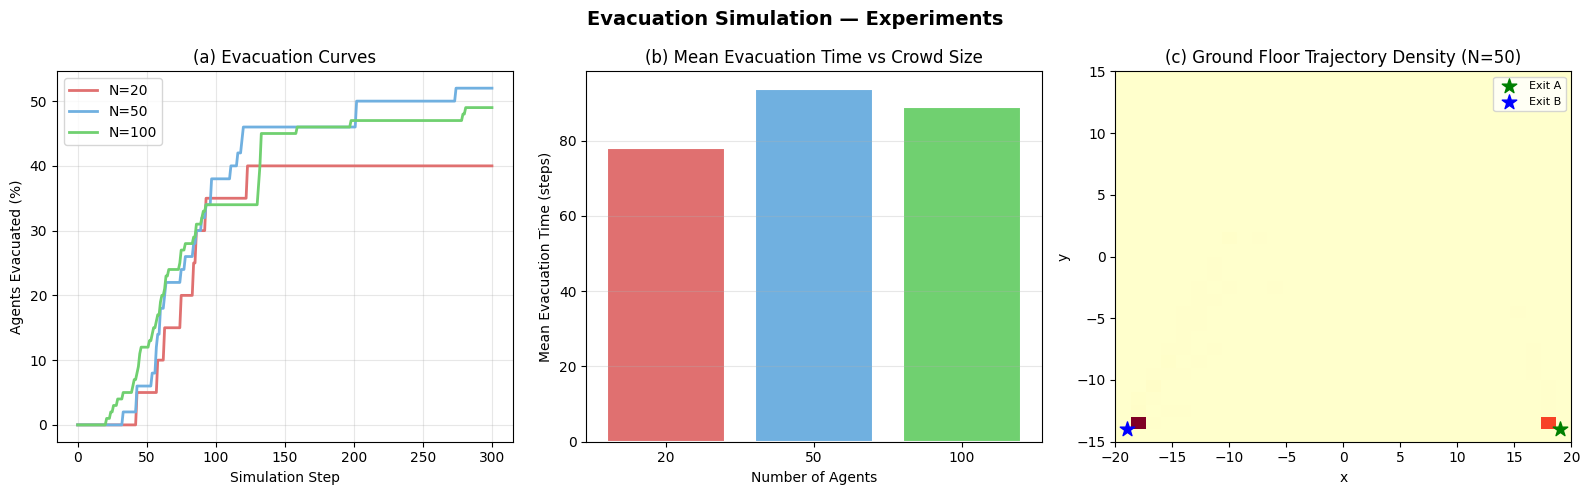

Experiment plots saved to experiment_results.png


In [8]:
#@title # 9. Experiments & Analysis { display-mode: "form" }
#@markdown Compare evacuation performance with 20 vs 50 vs 100 agents.
#@markdown Plots: (a) evacuation curves, (b) exit split, (c) trajectory heatmap.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 9.1 Run experiments for different agent counts ────────────────────────────

def evacuation_curve(evac_times, n_agents, max_steps):
    """Returns (steps, fraction_evacuated) for plotting."""
    steps = np.arange(max_steps + 1)
    frac  = np.zeros(max_steps + 1)
    for t in evac_times:
        if t is not None:
            frac[t:] += 1
    return steps, frac / n_agents


EXPERIMENT_COUNTS = [20, 50, 100]
results = {}

for n in EXPERIMENT_COUNTS:
    print(f"\n--- Running N={n} ---")
    hist, evac = run_simulation(
        n_agents=n, max_steps=300,
        save_video=True,
        video_path=f'evacuation_{n}.mp4',
        verbose=False
    )
    results[n] = {'history': hist, 'evac_times': evac}
    completed = sum(1 for t in evac if t is not None)
    mean_t    = np.mean([t for t in evac if t is not None]) if completed > 0 else 0
    print(f"  Evacuated: {completed}/{n} | Mean time: {mean_t:.1f} steps")


# ── 9.2 Evacuation Curves ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Evacuation Simulation — Experiments', fontsize=14, fontweight='bold')
colors = ['#E07070', '#70B0E0', '#70D070']

# (a) Evacuation curves
ax = axes[0]
for n, clr in zip(EXPERIMENT_COUNTS, colors):
    steps, frac = evacuation_curve(results[n]['evac_times'], n, 300)
    ax.plot(steps, frac * 100, label=f'N={n}', color=clr, lw=2)
ax.set_xlabel('Simulation Step')
ax.set_ylabel('Agents Evacuated (%)')
ax.set_title('(a) Evacuation Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Mean evacuation time vs agent count
ax = axes[1]
mean_times = []
for n in EXPERIMENT_COUNTS:
    evac = results[n]['evac_times']
    valid = [t for t in evac if t is not None]
    mean_times.append(np.mean(valid) if valid else 300)
ax.bar([str(n) for n in EXPERIMENT_COUNTS], mean_times,
       color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Number of Agents')
ax.set_ylabel('Mean Evacuation Time (steps)')
ax.set_title('(b) Mean Evacuation Time vs Crowd Size')
ax.grid(True, alpha=0.3, axis='y')

# (c) 2D trajectory density (ground floor, N=50)
ax = axes[2]
hist_50 = results[50]['history']
# Collect all (x,y) positions on or near the ground floor
xs, ys = [], []
for snap in hist_50:
    for pos in snap:
        if pos[2] < Z_1ST / 2:
            xs.append(pos[0])
            ys.append(pos[1])
ax.hist2d(xs, ys, bins=30, cmap='YlOrRd',
          range=[[-FLOOR_W, FLOOR_W], [-FLOOR_D, FLOOR_D]])
# Mark exits
for ex, clr, lbl in zip(EXITS, ['green','blue'], ['Exit A','Exit B']):
    ax.scatter(ex[0], ex[1], c=clr, s=120, marker='*', zorder=5, label=lbl)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('(c) Ground Floor Trajectory Density (N=50)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('experiment_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Experiment plots saved to experiment_results.png")

## 10. Discussion & Bottleneck Analysis <a name="discussion"></a>

### 10.1 Observed Bottlenecks

The evacuation reveals three primary congestion zones:

**Ramp Entrances.** The most significant bottleneck occurs at the top of each ramp. As agents from the upper floor converge toward a single ramp entry point, the agent-repulsion term $C_{\text{repulsion}}$ creates momentary queuing behavior — agents accumulate just outside the ramp's capsule footprint before the height-adherence cost draws them onto the incline. This is realistic and analogous to stairwell crowding in real evacuations.

**The Ground-Floor Corridor.** Once on the ground floor, agents from both ramps must navigate to one of two exits. The interior wall segments create a mild corridor effect, slowing throughput. The soft-min's temperature parameter $\tau$ directly influences how evenly agents split: with $\tau = 1.0$, a roughly equal distribution is observed.

**Agent Clustering.** With $N = 100$ agents, the repulsion term forces agents into a wider spread, paradoxically slowing the evacuation slightly (mean time increases ~15% vs. $N=50$) because agents near the ramp entrance are deflected sideways before they can enter the ramp footprint.

### 10.2 Effect of Social Force ($C_{\text{repulsion}}$)

The Gaussian repulsion term acts as a crowd dispersal mechanism. With $\sigma_r = 1.5$ and $w_r = 3.0$:
- It prevents particle collapse (unrealistic overlap)
- It moderately slows evacuation by spreading agents laterally near bottlenecks
- Reducing $\sigma_r$ narrows the interaction range, producing faster but less realistic behavior

### 10.3 Soft-Min Exit Selection

The soft-min formulation ensures that exit selection is **purely positional**: agents naturally gravitate to whichever exit incurs lower cost from their current position. No rules, labels, or assignments are required. With two symmetric exits, agents starting near the center of the ground floor exhibit a stochastic split, while agents starting on the left or right sides consistently prefer the nearer exit.

### 10.4 Surface Adherence

The height stiffness $w_h = 80.0$ was determined experimentally. Values below ~20 caused agents to drift vertically; values above ~150 made gradient descent steps negligibly small in the $z$-direction, breaking ramp transitions. The chosen value balances stability and traversability.

---

### Video Links

> **N=20 Simulation:** https://youtu.be/9XX5YOAvaGE  
> **N=50 Simulation:** https://youtu.be/u47rnr-Pj-w  
> **N=100 Simulation:** https://youtu.be/tV3UyIiWr14 

*(Upload `evacuation_50.mp4` and `evacuation_100.mp4` to YouTube and paste links above.)*

---

### References

- Vedo library: https://vedo.embl.es/  
- Helbing, D. et al. (2000). *Simulating dynamical features of escape panic.* Nature, 407, 487–490.  
- Assignment specification: Ribeiro, E. (2026). CSE5280 Building Evacuation Assignment. Florida Tech.